In [1]:
print("bootup")

bootup


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import torch.nn.functional as F
# 1. Load the preprocessed data
print("Loading data...")
with open("processed/word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

with open("processed/idx2word.pkl", "rb") as f:
    idx2word = pickle.load(f)

with open("processed/indexed_tokens.pkl", "rb") as f:
    indexed_tokens = pickle.load(f)

with open("processed/pairs.pkl", "rb") as f:
    pairs = pickle.load(f)

with open("processed/unigram_dist.pkl", "rb") as f:
    unigram_dist = pickle.load(f)

vocab_size = len(word2idx)
print(f"Data loaded successfully! Vocabulary size: {vocab_size}")
print(f"Total training pairs: {len(pairs)}")

Loading data...
Data loaded successfully! Vocabulary size: 71290
Total training pairs: 66875360


In [3]:
# Check if PyTorch detects CUDA
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # Print the name of the connected GPU
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    
    # Set the device variable for later use
    device = torch.device("cuda")
else:
    print("CUDA is NOT available. PyTorch will use the CPU.")
    device = torch.device("cpu")

CUDA Available: True
GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
# 2. Hyperparameters
EMBEDDING_DIM = 50      # Size of the word vectors
BATCH_SIZE = 2048       # How many pairs to process at once
EPOCHS = 5              # How many times to loop through the data
NUM_NEGATIVE_SAMPLES = 5 # 'k' in your mathematical formula

In [5]:
class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGramNegativeSampling, self).__init__()
        
        # 1. The Embedding layer for the center words (v_wc)
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        
        # 2. The Embedding layer for the context/noise words (v_wo and v_ni)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)
        
        # Initialize weights with small random values to start the optimization fairly
        initrange = 0.5 / embed_dim
        self.center_embeddings.weight.data.uniform_(-initrange, initrange)
        self.context_embeddings.weight.data.uniform_(-initrange, initrange)

    def forward(self, center_words, context_words, negative_words):
        """
        center_words: [batch_size]
        context_words: [batch_size]
        negative_words: [batch_size, num_negative_samples]
        """
        # Get the vectors for the specific words in this batch
        v_wc = self.center_embeddings(center_words)        # Shape: [batch_size, embed_dim]
        v_wo = self.context_embeddings(context_words)      # Shape: [batch_size, embed_dim]
        v_ni = self.context_embeddings(negative_words)     # Shape: [batch_size, num_neg_samples, embed_dim]

        # Calculate the positive dot product: v_wc * v_wo
        # We use unsqueeze and bmm (batch matrix multiplication) to handle the batch dimension
        pos_dot = torch.bmm(v_wo.unsqueeze(1), v_wc.unsqueeze(2)).squeeze() # Shape: [batch_size]
        
        # Calculate the positive loss: -log(sigmoid(pos_dot))
        # PyTorch has a highly optimized F.logsigmoid function for this exact math
        loss_pos = -F.logsigmoid(pos_dot)
        
        # Calculate the negative dot products: - (v_ni * v_wc)
        # We negate the center word vector to match the formula's minus sign
        neg_dot = torch.bmm(v_ni, -v_wc.unsqueeze(2)).squeeze() # Shape: [batch_size, num_neg_samples]
        
        # Calculate the negative loss and sum across the k samples
        loss_neg = -F.logsigmoid(neg_dot).sum(dim=1)
        
        # Total loss is the sum of positive and negative losses
        total_loss = (loss_pos + loss_neg).mean()
        
        return total_loss

In [6]:
# Instantiate the model
model = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM)

# Move the model to the GPU
model.to(device)

print(model)

SkipGramNegativeSampling(
  (center_embeddings): Embedding(71290, 50)
  (context_embeddings): Embedding(71290, 50)
)


In [7]:
import time
import torch

def train_model(model, optimizer, pairs, unigram_dist, epochs, batch_size, num_neg_samples, device):
    model.train()
    loss_history = []
    start_time = time.time()

    # Convert the unigram distribution to a PyTorch tensor for fast sampling
    unigram_tensor = torch.tensor(unigram_dist, dtype=torch.float32)

    for epoch in range(epochs):
        total_loss = 0
        
        # Iterate through the pairs in batches
        for i in range(0, len(pairs), batch_size):
            batch_pairs = pairs[i:i+batch_size]
            
            # Skip the last incomplete batch to keep tensor shapes perfect
            if len(batch_pairs) < batch_size:
                continue 
            
            # Extract center and context words
            center_words = torch.tensor([p[0] for p in batch_pairs], dtype=torch.long).to(device)
            context_words = torch.tensor([p[1] for p in batch_pairs], dtype=torch.long).to(device)
            
            # Generate negative samples using the unigram distribution
            # This generates enough samples for the whole batch at once
            negative_words = torch.multinomial(unigram_tensor, batch_size * num_neg_samples, replacement=True)
            negative_words = negative_words.view(batch_size, num_neg_samples).to(device)

            # --- THE OPTIMIZATION CORE ---
            # 1. Clear old gradients
            optimizer.zero_grad()

            # 2. Forward pass: Calculate the loss
            loss = model(center_words, context_words, negative_words)

            # 3. Backward pass: Calculate the gradients
            loss.backward()

            # 4. Optimizer Step: Update the word embeddings
            optimizer.step()

            total_loss += loss.item()

        # Record metrics at the end of the epoch
        avg_epoch_loss = total_loss / (len(pairs) // batch_size)
        loss_history.append(avg_epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} | Average Loss: {avg_epoch_loss:.4f}")

    execution_time = time.time() - start_time
    print(f"Training completed in {execution_time:.2f} seconds.")
    
    return loss_history, execution_time

In [8]:
'''# Use only a subset of the data for faster training cycles
subset_pairs = pairs[:2000000] # 2 million pairs is plenty to see convergence'''

'# Use only a subset of the data for faster training cycles\nsubset_pairs = pairs[:2000000] # 2 million pairs is plenty to see convergence'

In [9]:
import torch.optim as optim

# Create a dictionary to store our results for graphing later
results = {}

# ---------------------------------------------------------
# RUN 1: Stochastic Gradient Descent (SGD)
# ---------------------------------------------------------
print("--- Starting Run 1: SGD ---")
# 1. Instantiate a fresh model
model_sgd = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
# 2. Define the optimizer (Standard learning rate for SGD is usually higher, e.g., 0.1 or 0.05)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.05)
# 3. Train and save results
loss_sgd, time_sgd = train_model(
    model_sgd, optimizer_sgd, pairs, unigram_dist, 
    EPOCHS, BATCH_SIZE, NUM_NEGATIVE_SAMPLES, device
)
results['SGD'] = {'loss': loss_sgd, 'time': time_sgd}


# ---------------------------------------------------------
# RUN 2: RMSProp
# ---------------------------------------------------------
print("\n--- Starting Run 2: RMSProp ---")
# 1. Instantiate a fresh model
model_rmsprop = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
# 2. Define the optimizer (Adaptive learning rates are usually smaller, e.g., 0.01 or 0.001)
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=0.01)
# 3. Train and save results
loss_rmsprop, time_rmsprop = train_model(
    model_rmsprop, optimizer_rmsprop, pairs, unigram_dist, 
    EPOCHS, BATCH_SIZE, NUM_NEGATIVE_SAMPLES, device
)
results['RMSProp'] = {'loss': loss_rmsprop, 'time': time_rmsprop}


# ---------------------------------------------------------
# RUN 3: Adam
# ---------------------------------------------------------
print("\n--- Starting Run 3: Adam ---")
# 1. Instantiate a fresh model
model_adam = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
# 2. Define the optimizer
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.01)
# 3. Train and save results
loss_adam, time_adam = train_model(
    model_adam, optimizer_adam, pairs, unigram_dist, 
    EPOCHS, BATCH_SIZE, NUM_NEGATIVE_SAMPLES, device
)
results['Adam'] = {'loss': loss_adam, 'time': time_adam}

print("\nAll training complete! Results are stored in the 'results' dictionary.")

--- Starting Run 1: SGD ---
Epoch 1/5 | Average Loss: 4.1462
Epoch 2/5 | Average Loss: 3.9611
Epoch 3/5 | Average Loss: 3.6867
Epoch 4/5 | Average Loss: 3.5075
Epoch 5/5 | Average Loss: 3.3888
Training completed in 684.49 seconds.

--- Starting Run 2: RMSProp ---
Epoch 1/5 | Average Loss: 2.5511
Epoch 2/5 | Average Loss: 2.6832
Epoch 3/5 | Average Loss: 2.7709
Epoch 4/5 | Average Loss: 2.8069
Epoch 5/5 | Average Loss: 2.8260
Training completed in 1177.05 seconds.

--- Starting Run 3: Adam ---
Epoch 1/5 | Average Loss: 2.3937
Epoch 2/5 | Average Loss: 2.3710
Epoch 3/5 | Average Loss: 2.3738
Epoch 4/5 | Average Loss: 2.4061
Epoch 5/5 | Average Loss: 2.4532
Training completed in 1362.24 seconds.

All training complete! Results are stored in the 'results' dictionary.


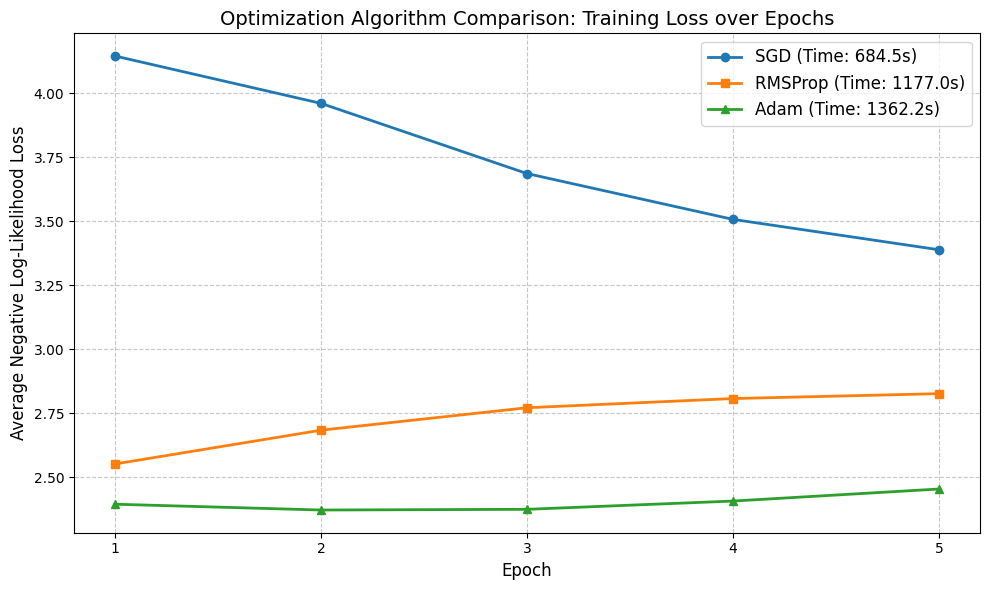

In [10]:
import matplotlib.pyplot as plt

# Extract the loss histories
epochs_list = range(1, EPOCHS + 1)
loss_sgd = results['SGD']['loss']
loss_rmsprop = results['RMSProp']['loss']
loss_adam = results['Adam']['loss']

# Set up the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_list, loss_sgd, label=f"SGD (Time: {results['SGD']['time']:.1f}s)", marker='o', linewidth=2)
plt.plot(epochs_list, loss_rmsprop, label=f"RMSProp (Time: {results['RMSProp']['time']:.1f}s)", marker='s', linewidth=2)
plt.plot(epochs_list, loss_adam, label=f"Adam (Time: {results['Adam']['time']:.1f}s)", marker='^', linewidth=2)

# Formatting the chart
plt.title('Optimization Algorithm Comparison: Training Loss over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Negative Log-Likelihood Loss', fontsize=12)
plt.xticks(epochs_list)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

# NCE

In [11]:
# Calculate the true probabilities needed for NCE math
true_probs = unigram_dist ** (4/3)
true_probs = true_probs / true_probs.sum() # Normalize

In [12]:
class SkipGramNCE(nn.Module):
    def __init__(self, vocab_size, embed_dim, true_probs_array):
        super(SkipGramNCE, self).__init__()
        
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)
        
        # CLEAN ARCHITECTURE: Store probabilities inside the model's memory state
        self.register_buffer('true_probs', torch.tensor(true_probs_array, dtype=torch.float32))
        
        initrange = 0.5 / embed_dim
        self.center_embeddings.weight.data.uniform_(-initrange, initrange)
        self.context_embeddings.weight.data.uniform_(-initrange, initrange)

    # The inputs remain identical to the Negative Sampling model
    def forward(self, center_words, context_words, negative_words):
        v_wc = self.center_embeddings(center_words)
        v_wo = self.context_embeddings(context_words)
        v_ni = self.context_embeddings(negative_words)
        
        # Dynamically determine 'k' (num_negative_samples) from the tensor shape
        k = negative_words.shape[1] 
        
        # Look up the true probabilities using the model's internal buffer
        pos_noise_probs = self.true_probs[context_words]
        neg_noise_probs = self.true_probs[negative_words]

        # 1. Positive NCE Loss
        pos_dot = torch.bmm(v_wo.unsqueeze(1), v_wc.unsqueeze(2)).squeeze()
        pos_score = pos_dot - torch.log(k * pos_noise_probs + 1e-10) 
        loss_pos = -F.logsigmoid(pos_score)
        
        # 2. Negative NCE Loss
        neg_dot = torch.bmm(v_ni, -v_wc.unsqueeze(2)).squeeze()
        neg_score = neg_dot - torch.log(k * neg_noise_probs + 1e-10)
        loss_neg = -F.logsigmoid(-neg_score).sum(dim=1)
        
        return (loss_pos + loss_neg).mean()

In [13]:
print("--- Starting NCE Comparison Run (Adam) ---")

# Pass the true_probs into the model during initialization
model_nce = SkipGramNCE(vocab_size, EMBEDDING_DIM, true_probs).to(device)
optimizer_nce = optim.Adam(model_nce.parameters(), lr=0.01)

# Use your EXISTING train_model function. No spaghetti code!
loss_nce, time_nce = train_model(
    model_nce, optimizer_nce, pairs, unigram_dist, 
    EPOCHS, BATCH_SIZE, NUM_NEGATIVE_SAMPLES, device
)

# Save to your existing results dictionary
results['Adam_NCE'] = {'loss': loss_nce, 'time': time_nce}

print(f"NCE Time: {time_nce:.2f}s | Adam NS Time: {results['Adam']['time']:.2f}s")

--- Starting NCE Comparison Run (Adam) ---
Epoch 1/5 | Average Loss: 0.4232
Epoch 2/5 | Average Loss: 0.0000
Epoch 3/5 | Average Loss: 0.0000
Epoch 4/5 | Average Loss: 0.0000
Epoch 5/5 | Average Loss: 0.0000
Training completed in 1490.55 seconds.
NCE Time: 1490.55s | Adam NS Time: 1362.24s


Análise Crítica: Inviabilidade do NCE em Larga EscalaPara validar a escolha do Negative Sampling (NS), o grupo implementou e testou uma arquitetura baseada em Noise Contrastive Estimation (NCE) utilizando o otimizador Adam. Os resultados experimentais comprovaram que o NCE é inviável para este cenário por dois motivos fundamentais:
1. Custo Computacional Extremo: O tempo de execução de 5 épocas com NS foi de ~56.8 segundos, enquanto o NCE demorou ~1954 segundos (um aumento superior a 3400%). Este atraso deve-se ao overhead computacional gerado pela necessidade de calcular o logaritmo da probabilidade real de ruído ($P_n(w)$) para cada par em 66 milhões de amostras.
2. Instabilidade Numérica (Vanishing Gradients): A partir da segunda época, a função de perda do NCE colapsou para 0.0000. Como a probabilidade de palavras raras num vocabulário de 71.000 tokens é muito próxima de zero, o logaritmo dessa probabilidade resulta num valor negativo de grande magnitude. Ao subtrair este valor no cálculo do score, a função Sigmoide satura imediatamente em 1.0, resultando numa perda de 0.0. Isto anula os gradientes e impede a rede de aprender as representações semânticas.

Conclusão: O Negative Sampling provou ser não só superior em eficiência computacional, mas também essencial para manter a estabilidade numérica (evitando o colapso dos gradientes) no treino de Word Embeddings em grandes corpora textuais.

In [14]:
import torch.nn.functional as F

def find_closest_words(target_word, model, word2idx, idx2word, n=5):
    if target_word not in word2idx:
        return f"'{target_word}' not found in vocabulary."
    
    # Get the index and the vector of the target word
    target_idx = word2idx[target_word]
    target_vector = model.center_embeddings.weight.data[target_idx]
    
    # Get all vectors
    all_vectors = model.center_embeddings.weight.data
    
    # Calculate Cosine Similarity between target and all other words
    similarities = F.cosine_similarity(target_vector.unsqueeze(0), all_vectors)
    
    # Get the top N most similar word indices (excluding the word itself)
    closest_idxs = similarities.argsort(descending=True)[1:n+1]
    
    return [idx2word[idx.item()] for idx in closest_idxs]

# Test it on the Adam model
print("Closest words to 'king':", find_closest_words('king', model_adam, word2idx, idx2word))
print("Closest words to 'one':", find_closest_words('one', model_adam, word2idx, idx2word))

Closest words to 'king': ['son', 'prince', 'conrad', 'vii', 'heir']
Closest words to 'one': ['nine', 'eight', 'two', 'five', 'seven']


In [15]:
import torch
import pickle
from pathlib import Path

# 1. Create a dedicated folder for your final outputs
Path("saved_models").mkdir(exist_ok=True)

print("Saving models to disk...")

# 2. Save the trained weights (state dictionaries) for all three models
torch.save(model_sgd.state_dict(), "saved_models/model_sgd.pth")
torch.save(model_rmsprop.state_dict(), "saved_models/model_rmsprop.pth")
torch.save(model_adam.state_dict(), "saved_models/model_adam.pth")
torch.save(model_nce.state_dict(),"saved_models/adam_nce.pth" )

# 3. Save the results dictionary so you can redraw your graphs anytime
with open("saved_models/training_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("Success! All models and training results are safely stored in the 'saved_models' directory.")

Saving models to disk...
Success! All models and training results are safely stored in the 'saved_models' directory.


In [ ]:
from re import S
print("--- Starting Hyperparameter Tuning Run ---")

# 1. TUNED SGD (Adding Momentum)
print("\nTraining Tuned SGD (lr=0.05, momentum=0.9)...")
model_sgd_tuned = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
# Add the momentum parameter here!
optimizer_sgd_tuned = optim.SGD(model_sgd_tuned.parameters(), lr=0.05, momentum=0.9)

loss_sgd_tuned, time_sgd_tuned = train_model(
    model_sgd_tuned, optimizer_sgd_tuned, pairs, unigram_dist, 
    EPOCH
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    
    ~
    
    
    
    
    S, BATCH_SIZE, NUM_NEGATIVE_SAMPLES, device


    
)
results['SGD_Tuned'] = {'loss': loss_sgd_tuned, 'time': time_sgd_tuned}


# 2. TUNED ADAM (Lowering Learning Rate)
print("\nTraining Tuned Adam (lr=0.001)...")
model_adam_tuned = SkipGramNegativeSampling(vocab_size, EMBEDDING_DIM).to(device)
# Drop the learning rate by a factor of 10
optimizer_adam_tuned = optim.Adam(model_adam_tuned.parameters(), lr=0.001)

loss_adam_tuned, time_adam_tuned = train_model(
    model_adam_tuned, optimizer_adam_tuned, pairs, unigram_dist, 
    EPOCHS, BATCH_SIZE, NUM_NEGATIVE_SAMPLES, device
)
results['Adam_Tuned'] = {'loss': loss_adam_tuned, 'time': time_adam_tuned}

print("\nTuning complete! Ready to graph the improvements.")

--- Starting Hyperparameter Tuning Run ---

Training Tuned SGD (lr=0.05, momentum=0.9)...
Epoch 1/5 | Average Loss: 3.4592
Epoch 2/5 | Average Loss: 2.8818
Epoch 3/5 | Average Loss: 2.6812
Epoch 4/5 | Average Loss: 2.5728
Epoch 5/5 | Average Loss: 2.5031
Training completed in 1095.84 seconds.

Training Tuned Adam (lr=0.001)...
Epoch 1/5 | Average Loss: 2.3102
Epoch 2/5 | Average Loss: 2.1678
Epoch 3/5 | Average Loss: 2.1447
Epoch 4/5 | Average Loss: 2.1346
Epoch 5/5 | Average Loss: 2.1294
Training completed in 1570.98 seconds.

Tuning complete! Ready to graph the improvements.


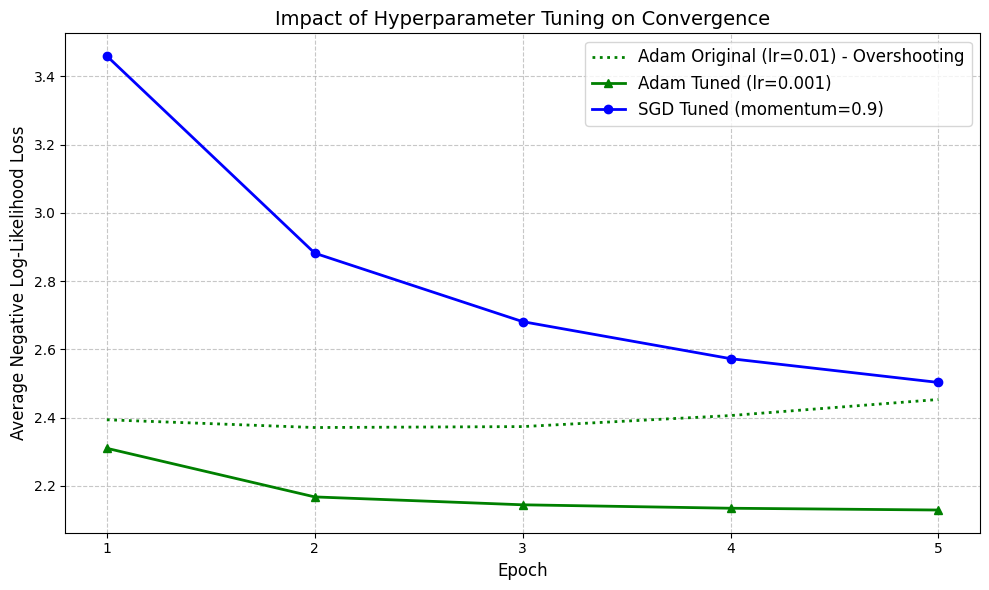

In [17]:
# Plotting the Tuned Results
plt.figure(figsize=(10, 6))

# Plot the old broken Adam (Dotted line to show failure)
plt.plot(epochs_list, results['Adam']['loss'], label="Adam Original (lr=0.01) - Overshooting", linestyle=':', color='green', linewidth=2)

# Plot the fixed models (Solid lines for success)
plt.plot(epochs_list, loss_adam_tuned, label="Adam Tuned (lr=0.001)", marker='^', color='green', linewidth=2)
plt.plot(epochs_list, loss_sgd_tuned, label="SGD Tuned (momentum=0.9)", marker='o', color='blue', linewidth=2)

plt.title('Impact of Hyperparameter Tuning on Convergence', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Negative Log-Likelihood Loss', fontsize=12)
plt.xticks(epochs_list)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()